In [2]:
import sys
print(sys.executable)

/Users/eliengandu/Documents/Programming/chess-analytics/venv/bin/python


In [3]:
%pip install requests chess pandas

     |████████████████████████████████| 73 kB 1.6 MB/s eta 0:00:01
     |████████████████████████████████| 6.1 MB 36.5 MB/s eta 0:00:01
     |████████████████████████████████| 11.6 MB 16.6 MB/s eta 0:00:01
     |████████████████████████████████| 131 kB 14.4 MB/s eta 0:00:01    |██████████████████████▌         | 92 kB 24.2 MB/s eta 0:00:01
     |████████████████████████████████| 136 kB 21.2 MB/s eta 0:00:01
     |████████████████████████████████| 369 kB 54.0 MB/s eta 0:00:01
     |████████████████████████████████| 68 kB 10.3 MB/s eta 0:00:01
     |████████████████████████████████| 348 kB 42.7 MB/s eta 0:00:01
     |████████████████████████████████| 6.9 MB 34.4 MB/s eta 0:00:01
     |████████████████████████████████| 508 kB 45.4 MB/s eta 0:00:01
Using legacy 'setup.py install' for chess, since package 'wheel' is not installed.
    Running setup.py install for chess ... done
You should consider upgrading via the '/Users/eliengandu/Documents/Programming/chess-analytics/venv/bin/python -m p

In [4]:
import requests
print("it works")

it works


## Ingestion

The API exposes games one month at a time. First fetch the list of monthly
archive URLs, then pull each one. Requests are made serially with a delay —
chess.com rate-limits on concurrency, not volume.

The API also rejects requests without a User-Agent header, which is why one
is set explicitly.

In [6]:
url = "https://api.chess.com/pub/player/thekinghunter003/games/archives"
print(url)

https://api.chess.com/pub/player/thekinghunter003/games/archives


In [7]:
response = requests.get(url)
print(response.status_code)

403


In [8]:
headers = {"User-Agent": "chess-analytics-personal-project"}
response = requests.get(url, headers=headers)
print(response.status_code)

200


In [9]:
data = response.json()
print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['archives'])


In [10]:
archives = data["archives"]
print(len(archives))
print(archives[0])
print(archives[-1])


23
https://api.chess.com/pub/player/thekinghunter003/games/2024/08
https://api.chess.com/pub/player/thekinghunter003/games/2026/09


In [11]:
month_url = archives[-1]
response = requests.get(month_url, headers=headers)
games = response.json()["games"]
print(len(games))

9


In [12]:
game = games[0]
print(game.keys())

dict_keys(['url', 'pgn', 'time_control', 'end_time', 'rated', 'accuracies', 'tcn', 'uuid', 'initial_setup', 'fen', 'time_class', 'rules', 'white', 'black', 'eco', 'tournament'])


## Normalising which side I played

There's no "my rating" or "my result" field — the data is structured as white
and black. Every game requires checking which side matches my username before
anything downstream will be correct.

This is the single most important step in the ingestion. Get it wrong and every
subsequent query is silently broken.

In [13]:
username = "thekinghunter003"

for game in games:
    if game["white"]["username"].lower() == username:
        me = game["white"]
        opponent = game["black"]
    else:
        me = game["black"]
        opponent = game["white"]
    print(me["rating"], me["result"], "vs", opponent["rating"])

1236 resigned vs 1398
1235 timeout vs 1720
1239 win vs 1060
1231 resigned vs 1251
1232 win vs 826
1229 resigned vs 1473
1237 win vs 1232
1229 checkmated vs 1258
1227 resigned vs 1595


In [14]:
import pandas as pd

rows = []
for game in games:
    if game["white"]["username"].lower() == username:
        me, opponent, color = game["white"], game["black"], "white"
    else:
        me, opponent, color = game["black"], game["white"], "black"
    rows.append({
        "color": color,
        "my_rating": me["rating"],
        "opp_rating": opponent["rating"],
        "result": me["result"],
        "time_class": game["time_class"],
        "eco": game["eco"].split("/")[-1],
    })

df = pd.DataFrame(rows)
df

,color,my_rating,opp_rating,result,time_class,eco
0,black,1236,1398,resigned,blitz,Reti-Opening-Kings-Indian-Attack-Symmetrical-D...
1,white,1235,1720,timeout,blitz,Sicilian-Defense-Open-Dragon-Classical-Attack-...
2,white,1239,1060,win,blitz,Scotch-Game-Scotch-Gambit-Dubois-Reti-Defense
3,black,1231,1251,resigned,blitz,Caro-Kann-Defense
4,white,1232,826,win,blitz,French-Defense-Exchange-Variation...6.Bd3-O-O-...
5,white,1229,1473,resigned,blitz,Modern-Defense-with-1-e4-2.d4-Bg7-3.Nf3-d6-4.Be3
6,black,1237,1232,win,blitz,Indian-Game-2.Bf4-g6-3.e3-Bg7
7,white,1229,1258,checkmated,blitz,Sicilian-Defense-Taimanov-Variation-5.Nc3
8,black,1227,1595,resigned,blitz,Indian-Game-Spielmann-Indian-Variation...4.exd...


In [15]:
import pandas as pd

rows = []
for game in games:
    if game["white"]["username"].lower() == username:
        me, opponent, color = game["white"], game["black"], "white"
    else:
        me, opponent, color = game["black"], game["white"], "black"
    rows.append({
        "color": color,
        "my_rating": me["rating"],
        "opp_rating": opponent["rating"],
        "result": me["result"],
        "time_class": game["time_class"],
        "eco": game["eco"].split("/")[-1],
        "opening_short": game["eco"].split("/")[-1].split("-")[0],
    })

df = pd.DataFrame(rows)
df

,color,my_rating,opp_rating,result,time_class,eco,opening_short
0,black,1236,1398,resigned,blitz,Reti-Opening-Kings-Indian-Attack-Symmetrical-D...,Reti
1,white,1235,1720,timeout,blitz,Sicilian-Defense-Open-Dragon-Classical-Attack-...,Sicilian
2,white,1239,1060,win,blitz,Scotch-Game-Scotch-Gambit-Dubois-Reti-Defense,Scotch
3,black,1231,1251,resigned,blitz,Caro-Kann-Defense,Caro
4,white,1232,826,win,blitz,French-Defense-Exchange-Variation...6.Bd3-O-O-...,French
5,white,1229,1473,resigned,blitz,Modern-Defense-with-1-e4-2.d4-Bg7-3.Nf3-d6-4.Be3,Modern
6,black,1237,1232,win,blitz,Indian-Game-2.Bf4-g6-3.e3-Bg7,Indian
7,white,1229,1258,checkmated,blitz,Sicilian-Defense-Taimanov-Variation-5.Nc3,Sicilian
8,black,1227,1595,resigned,blitz,Indian-Game-Spielmann-Indian-Variation...4.exd...,Indian


In [16]:
import time

all_games = []
for archive_url in archives:
    r = requests.get(archive_url, headers=headers)
    all_games.extend(r.json()["games"])
    print(archive_url[-7:], len(all_games))
    time.sleep(1)

print("total:", len(all_games))

2024/08 0
2024/12 2
2025/01 2
2025/02 235
2025/03 613
2025/04 1166
2025/05 1650
2025/06 1904
2025/07 2311
2025/08 2648
2025/09 2974
2025/10 3347
2025/11 3647
2025/12 3936
2026/01 4215
2026/02 4448
2026/03 4758
2026/04 4955
2026/05 5182
2026/06 5330
2026/07 5519
2026/08 5921
2026/09 5930
total: 5930


In [18]:
rows = []
for game in all_games:
    if game["white"]["username"].lower() == username:
        me, opponent, color = game["white"], game["black"], "white"
    else:
        me, opponent, color = game["black"], game["white"], "black"

    eco_url = game.get("eco", "")
    eco_name = eco_url.split("/")[-1] if eco_url else None

    rows.append({
        "color": color,
        "my_rating": me["rating"],
        "opp_rating": opponent["rating"],
        "result": me["result"],
        "time_class": game["time_class"],
        "rules": game["rules"],
        "rated": game["rated"],
        "end_time": game["end_time"],
        "eco": eco_name,
        "opening_short": eco_name.split("-")[0] if eco_name else None,
    })

df = pd.DataFrame(rows)
print(len(df))
df.head()

5930


,color,my_rating,opp_rating,result,time_class,rules,rated,end_time,eco,opening_short
0,white,800,528,win,daily,chess,True,1733455300,Vienna-Game,Vienna
1,black,865,501,win,daily,chess,True,1734549692,Italian-Game,Italian
2,white,670,837,timeout,rapid,chess,True,1739746155,Caro-Kann-Defense-Classical-Variation,Caro
3,white,754,539,win,rapid,chess,True,1739746541,Vienna-Game-Falkbeer-Stanley-Variation,Vienna
4,black,843,735,win,rapid,chess,True,1739747126,Three-Knights-Opening-3...Bc5-4.Nxe5-Nxe5-5.d4,Three


In [19]:
print(df["time_class"].value_counts())
print()
print(df["rules"].value_counts())
print()
print(df["result"].value_counts())

time_class
blitz     4801
rapid     1089
daily       20
bullet      20
Name: count, dtype: int64

rules
chess       5724
chess960     206
Name: count, dtype: int64

result
win                   3012
resigned              1945
checkmated             403
timeout                365
repetition              59
abandoned               57
insufficient            34
stalemate               25
timevsinsufficient      14
agreed                  14
50move                   2
Name: count, dtype: int64


## Filtering

Dropping Chess960 (different game, opening analysis meaningless) and unrated
games. Leaves 5,695 games — 4,595 blitz and 1,061 rapid.

In [20]:


clean = df[(df["rules"] == "chess") & (df["rated"] == True)]
print(len(clean))
print(clean["time_class"].value_counts())

5695
time_class
blitz     4595
rapid     1061
bullet      20
daily       19
Name: count, dtype: int64


In [23]:
import os
os.makedirs("../data", exist_ok=True)

In [24]:
clean.to_csv("../data/games.csv", index=False)
print("saved", len(clean), "games")

saved 5695 games


In [25]:
print(open("../.gitignore").read())

# Byte-compiled / optimized / DLL files
__pycache__/
*.py[codz]
*$py.class

# C extensions
*.so

# Distribution / packaging
.Python
build/
develop-eggs/
dist/
downloads/
eggs/
.eggs/
lib/
lib64/
parts/
sdist/
var/
wheels/
share/python-wheels/
*.egg-info/
.installed.cfg
*.egg
MANIFEST

# PyInstaller
#   Usually these files are written by a python script from a template
#   before PyInstaller builds the exe, so as to inject date/other infos into it.
*.manifest
*.spec

# Installer logs
pip-log.txt
pip-delete-this-directory.txt

# Unit test / coverage reports
htmlcov/
.tox/
.nox/
.coverage
.coverage.*
.cache
nosetests.xml
coverage.xml
*.cover
*.py.cover
.hypothesis/
.pytest_cache/
cover/

# Translations
*.mo
*.pot

# Django stuff:
*.log
local_settings.py
db.sqlite3
db.sqlite3-journal

# Flask stuff:
instance/
.webassets-cache

# Scrapy stuff:
.scrapy

# Sphinx documentation
docs/_build/

# PyBuilder
.pybuilder/
target/

# Jupyter Notebook
.ipynb_checkpoints

# IPython
profile_default/
ipyt

In [26]:
with open("../.gitignore", "a") as f:
    f.write("\ndata/\n*.db\n")

In [27]:
print(open("../.gitignore").read())

# Byte-compiled / optimized / DLL files
__pycache__/
*.py[codz]
*$py.class

# C extensions
*.so

# Distribution / packaging
.Python
build/
develop-eggs/
dist/
downloads/
eggs/
.eggs/
lib/
lib64/
parts/
sdist/
var/
wheels/
share/python-wheels/
*.egg-info/
.installed.cfg
*.egg
MANIFEST

# PyInstaller
#   Usually these files are written by a python script from a template
#   before PyInstaller builds the exe, so as to inject date/other infos into it.
*.manifest
*.spec

# Installer logs
pip-log.txt
pip-delete-this-directory.txt

# Unit test / coverage reports
htmlcov/
.tox/
.nox/
.coverage
.coverage.*
.cache
nosetests.xml
coverage.xml
*.cover
*.py.cover
.hypothesis/
.pytest_cache/
cover/

# Translations
*.mo
*.pot

# Django stuff:
*.log
local_settings.py
db.sqlite3
db.sqlite3-journal

# Flask stuff:
instance/
.webassets-cache

# Scrapy stuff:
.scrapy

# Sphinx documentation
docs/_build/

# PyBuilder
.pybuilder/
target/

# Jupyter Notebook
.ipynb_checkpoints

# IPython
profile_default/
ipyt

## How do the losses actually happen?

Starting with the basics — win rate, colour, and the manner of losing. The
`result` field is asymmetric: winners get "win", losers get the reason
(resigned, checkmated, timeout), so it tells you how a game ended for the
player who lost it.


In [28]:
rapid = clean[clean["time_class"] == "rapid"]

def outcome(r):
    if r == "win":
        return "win"
    if r in ["agreed", "repetition", "stalemate", "insufficient", "50move", "timevsinsufficient"]:
        return "draw"
    return "loss"

rapid = rapid.copy()
rapid["outcome"] = rapid["result"].apply(outcome)

print(rapid["outcome"].value_counts(normalize=True))

outcome
win     0.539114
loss    0.437323
draw    0.023563
Name: proportion, dtype: float64


**Finding:** 53.9% win rate in rapid — above even, so this isn't a hard ceiling.
Combined with the rating history (670 → 1500 in 18 months), the plateau looks
more like deceleration than a wall.

Colour makes almost no difference: 54.9% as white, 52.9% as black. That's the
normal first-move advantage. Not a factor.

In [29]:
print(rapid.groupby("color")["outcome"].value_counts(normalize=True).unstack())

outcome      draw      loss       win
color                                
black    0.018904  0.451796  0.529301
white    0.028195  0.422932  0.548872


### Where do the losses come from — the board or the clock?

In [30]:
blitz = clean[clean["time_class"] == "blitz"].copy()
blitz["outcome"] = blitz["result"].apply(outcome)

for name, d in [("rapid", rapid), ("blitz", blitz)]:
    losses = d[d["outcome"] == "loss"]
    print(name, len(losses))
    print(losses["result"].value_counts(normalize=True).round(3))
    print()

rapid 464
result
resigned      0.741
checkmated    0.194
abandoned     0.050
timeout       0.015
Name: proportion, dtype: float64

blitz 2198
result
resigned      0.702
timeout       0.153
checkmated    0.133
abandoned     0.012
Name: proportion, dtype: float64



**Finding:** resignations are 70% of losses in both rapid and blitz.

Blitz timeouts are 15.3% of losses against rapid's 1.5% — ten times higher, so
the clock is genuinely a blitz problem. But even in blitz, resigning dominates.

Resigning means the position was already lost and I knew it. So the primary
cause is positions going wrong, not running out of time. That's the opposite of
what most players at this level assume about themselves.

### Do accuracy scores explain the losses?

Chess.com computes an accuracy score for many games — how closely each side's
moves matched engine choices. This is free engine analysis already sitting in
the data, so it's worth checking before running Stockfish ourselves.

The question: how far apart is my accuracy in wins versus losses, and is the
gap bigger in rapid or blitz?

In [31]:
rows = []
for game in all_games:
    if "accuracies" not in game:
        continue
    if game["white"]["username"].lower() == username:
        me, side = game["white"], "white"
    else:
        me, side = game["black"], "black"
    rows.append({
        "time_class": game["time_class"],
        "result": me["result"],
        "my_accuracy": game["accuracies"][side],
        "end_time": game["end_time"],
    })

acc = pd.DataFrame(rows)
acc["outcome"] = acc["result"].apply(outcome)
print(len(acc), "games have accuracy scores")
print(acc.groupby(["time_class", "outcome"])["my_accuracy"].mean().round(1))

4041 games have accuracy scores
time_class  outcome
blitz       draw       78.3
            loss       70.2
            win        78.8
bullet      draw       71.7
            loss       70.9
            win        79.3
daily       loss       73.8
            win        78.5
rapid       draw       76.2
            loss       69.0
            win        78.4
Name: my_accuracy, dtype: float64


**Finding:** wins average 78–79% accuracy, losses 69–70% — a ~9 point gap,
consistent across rapid, blitz and bullet.

The consistency matters. If time pressure were the main driver, the gap would
widen sharply in bullet. It doesn't. That suggests losses come from a few
decisive errors rather than generally worse play — which fits resignations
being 70% of losses.

Next: is the accuracy distribution bimodal (mostly-good games with occasional
collapses) or a smooth spread?

### Is the accuracy distribution bimodal?

If losses come from occasional collapses, we'd expect a cluster of bad games
sitting apart from the main body. If it's a smooth spread, the losses are
just the low tail of normal variation — a different problem entirely.

In [33]:
%pip install matplotlib

     |████████████████████████████████| 8.3 MB 19.8 MB/s eta 0:00:01
     |████████████████████████████████| 122 kB 28.1 MB/s eta 0:00:01
     |████████████████████████████████| 66 kB 13.8 MB/s eta 0:00:01
     |████████████████████████████████| 2.6 MB 39.1 MB/s eta 0:00:01
     |████████████████████████████████| 268 kB 44.5 MB/s eta 0:00:01
     |████████████████████████████████| 5.4 MB 40.2 MB/s eta 0:00:01
You should consider upgrading via the '/Users/eliengandu/Documents/Programming/chess-analytics/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [35]:
%pip freeze > ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


count    623.0
mean      74.6
std       11.1
min        0.0
25%       68.1
50%       75.5
75%       82.0
max      100.0
Name: my_accuracy, dtype: float64

wins  : {0.1: 66.2, 0.25: 72.4, 0.5: 79.3, 0.75: 85.5, 0.9: 90.0}
losses: {0.1: 56.1, 0.25: 62.8, 0.5: 70.4, 0.75: 77.3, 0.9: 80.1}


Matplotlib is building the font cache; this may take a moment.


<Axes: title={'center': 'Rapid accuracy distribution'}, ylabel='Frequency'>

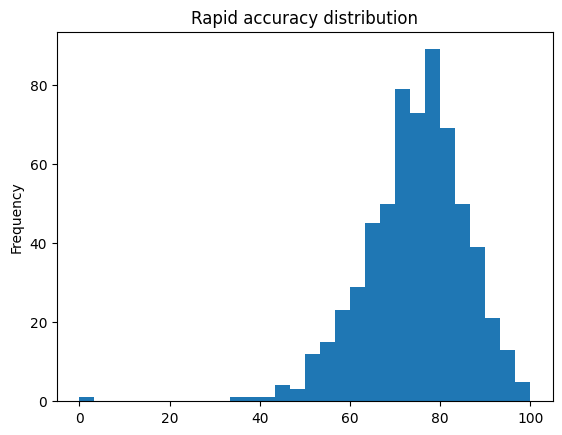

In [36]:
r = acc[acc["time_class"] == "rapid"]

print(r["my_accuracy"].describe().round(1))
print()
print("wins  :", r[r.outcome=="win"]["my_accuracy"].quantile([.1,.25,.5,.75,.9]).round(1).to_dict())
print("losses:", r[r.outcome=="loss"]["my_accuracy"].quantile([.1,.25,.5,.75,.9]).round(1).to_dict())

r["my_accuracy"].plot.hist(bins=30, title="Rapid accuracy distribution")

**Finding:** the distribution is NOT bimodal. Losses sit ~9-10 points below
wins at every percentile — the whole distribution shifts down rather than a
subset collapsing.

Reframes the earlier finding: it isn't occasional disasters, it's that losing
games are played worse throughout.

⚠️ Min accuracy of 0.0 suggests abandoned games are polluting the loss numbers.
Filter those before concluding.

### Removing abandoned games

Minimum accuracy of 0.0 indicates abandoned games are in the loss data.
Those aren't chess outcomes — they're walking away — so they distort the
picture. Re-run without them.

In [37]:
r2 = r[r["result"] != "abandoned"]
print("dropped", len(r) - len(r2), "abandoned games")
print()
print("wins  :", r2[r2.outcome=="win"]["my_accuracy"].quantile([.1,.5,.9]).round(1).to_dict())
print("losses:", r2[r2.outcome=="loss"]["my_accuracy"].quantile([.1,.5,.9]).round(1).to_dict())
print()
print(r2.groupby("outcome")["my_accuracy"].agg(["count","mean","min"]).round(1))

dropped 7 abandoned games

wins  : {0.1: 66.2, 0.5: 79.3, 0.9: 90.0}
losses: {0.1: 56.3, 0.5: 70.4, 0.9: 80.0}

         count  mean   min
outcome                   
draw        18  76.2  58.7
loss       240  69.1  35.9
win        358  78.4  42.7


### Does accuracy depend on opponent strength?

If accuracy drops sharply against stronger opponents, that points at something
psychological or preparation-related. If it's flat, the errors are self-inflicted
regardless of who's across the board — which is a very different problem.

In [38]:
rows = []
for game in all_games:
    if "accuracies" not in game:
        continue
    if game["white"]["username"].lower() == username:
        me, opp, side = game["white"], game["black"], "white"
    else:
        me, opp, side = game["black"], game["white"], "black"
    rows.append({
        "time_class": game["time_class"],
        "result": me["result"],
        "my_accuracy": game["accuracies"][side],
        "my_rating": me["rating"],
        "opp_rating": opp["rating"],
    })

acc = pd.DataFrame(rows)
acc["outcome"] = acc["result"].apply(outcome)
acc["rating_diff"] = acc["opp_rating"] - acc["my_rating"]

r = acc[(acc.time_class=="rapid") & (acc.result!="abandoned")].copy()
r["bucket"] = pd.cut(r["rating_diff"],
                     [-999,-100,-25,25,100,999],
                     labels=["much weaker","weaker","even","stronger","much stronger"])

print(r.groupby("bucket", observed=True).agg(
    games=("my_accuracy","size"),
    accuracy=("my_accuracy","mean"),
    win_rate=("outcome", lambda x: (x=="win").mean())
).round(2))

               games  accuracy  win_rate
bucket                                  
much weaker      194     77.39      0.78
weaker           104     73.05      0.63
even              72     74.80      0.58
stronger         100     72.83      0.42
much stronger    146     73.57      0.39


**Finding:** accuracy is flat across opponent strength (73-75 everywhere) while
win rate falls from 63% to 39%. I play the same chess regardless of opponent —
results are determined by their level, not by anything situational in mine.

Rules out: openings, colour, and opponent-dependent psychology. What's left is
the baseline level itself, which needs move-level analysis to diagnose.